# Statystyczne metody przetwarzania danych 

## Laboratorium 2 - algorytm Najbliższego Sąsiada (NN)


### Opis
Celem jest zbadanie danych i opracowanie algorytmu klasyfikacji liści. Do tego celu należy zaimplementować i zastosować klasyfikator najbliższego sąsiada - NN (Nearest Neighbor).

Ukończony projekt powinien:
* Klasyfikować dwie klasy liści:
    * `Populus nigra` - klasa nr 3, 
    * `Quercus robur` - klasa nr 5.

### Zbiór danych

Zbiór danych znajduje się w `dataset/dataset.npz`. Jest to zbiór danych pobrany i zmodyfikowany z adresu: <https://archive.ics.uci.edu/ml/datasets/leaf>.

### Przesyłanie zadań

Wszystkie pliki należy spakować archiwizatorem **zip** i przesłać za pośrednictwem platformy WIKAMP. Poniżej oczekiwana zawartość archiwum:

```
+-- 📂 [IMIE I NAZWISKO].zip
    +-- 📜 Lab01.ipynb
    +-- 📂 dataset
        +-- 📜 dataset.npz
        +-- 📜 ReadMe.pdf
```

### Zadanie 1

Wczytaj dane z pliku `dataset.npz`. Plik ten zawiera zbiór danych podzielony na dwa podzbiory: treningowy `train` i testowy `test`. Każdy z nich zawiera cechy oraz indeksy klas. Dokładny opis zbioru danych znajduje się w pliku `ReadMe.pdf`.

> Podpowiedź: Możesz wykorzystać poniższy kod:
```python
with open('./dataset/dataset.npz', 'rb') as f:
    data = np.load(f)
    train, test = data['train'], data['test']
```

In [40]:
import numpy as np
import pandas as pd

In [41]:
with open('./dataset/dataset.npz', 'rb') as f:
    data = np.load(f)
    train, test = data['train'], data['test']

In [42]:
train[:5]

array([[3.6000e+01, 1.0000e+00, 3.9093e-01, 1.1025e+00, 7.3351e-01,
        7.2022e-01, 6.9474e-01, 1.7954e-01, 7.6072e-02, 1.0532e+00,
        5.9213e-02, 1.5747e-01, 2.4197e-02, 9.5408e-03, 2.4731e-04,
        1.2042e+00],
       [5.0000e+00, 4.0000e+00, 9.3671e-01, 2.4151e+00, 7.2980e-01,
        8.1793e-01, 8.6491e-01, 3.3439e-01, 8.0539e-02, 1.1805e+00,
        4.8722e-02, 1.2051e-01, 1.4314e-02, 3.9983e-03, 3.7216e-04,
        1.3083e+00],
       [2.9000e+01, 1.0000e+00, 8.3750e-01, 1.9512e+00, 4.9050e-01,
        9.6800e-01, 9.8246e-01, 6.5138e-01, 1.6224e-02, 4.7908e-02,
        5.1195e-03, 3.5621e-02, 1.2673e-03, 3.2240e-04, 1.1238e-05,
        2.3514e-01],
       [3.5000e+01, 3.0000e+00, 9.0755e-01, 2.5820e+00, 6.2394e-01,
        9.6837e-01, 9.9825e-01, 5.5674e-01, 3.1714e-02, 1.8305e-01,
        7.9387e-02, 1.6213e-01, 2.5613e-02, 7.4124e-03, 6.9878e-04,
        1.6951e+00],
       [3.2000e+01, 7.0000e+00, 8.8485e-01, 2.2398e+00, 5.5754e-01,
        9.7997e-01, 9.9825e-01, 

### Zadanie 2

Sprawdź: 
* ile jest wszystkich próbek z zbiorze, 
* ile jest próbek w poszczegónych klasach.

Czy zauważyłeś jakieś problemy związane z tym zbiorem danych?

In [122]:
print(f"Number of samples:\nIn traning set: {len(train)}\nIn test set {len(test)}\n")

Number of samples:
In traning set: 2244
In test set 1496



In [44]:
train_df = pd.DataFrame(train)
test_df = pd.DataFrame(test)
train_df[0].value_counts().sort_index()

0
1.0      77
2.0      66
3.0      55
4.0      66
5.0      77
6.0      44
7.0      44
8.0      33
9.0     121
10.0     88
11.0     88
12.0     77
13.0     99
14.0     66
15.0     66
22.0    121
23.0     77
24.0     77
25.0     66
26.0     99
27.0     55
28.0     66
29.0    110
30.0     77
31.0     77
32.0     66
33.0     66
34.0     99
35.0     88
36.0     33
Name: count, dtype: int64

Mało próbek na klasę, niektóre klasy mają po 120, inne tylko 33

Widać również, że dane nie są znormalizowane, w kolumnie pierwszej liczby są wiekszych rzędów niż w innych co może negatywnie wpływać na klasyfikator KNN

### Zadanie 3

Wybierz wiersze należące do poniższych klas (rodzaje liści) i zapisz w zmiennych `train_new` oraz `test_new`:
* `Populus nigra` - klasa nr 3, 
* `Quercus robur` - klasa nr 5.

Aby wybrać jedynie te wiersze, które należą do wymienionych klas, należy przefiltrować dane po kolumnie o indeksie `0`:


In [45]:
train_new = train_df[(train_df[0] == 3) | (train_df[0] == 5)]
test_new = test_df[(test_df[0] == 3) | (test_df[0] == 5)]

In [46]:
print(f"Length train: {len(train_new)}, test: {len(test_new)}")

Length train: 132, test: 110


### Zadanie 4

A) Wybierz dwie dowolne cechy (*features*), np. o indeksach 4 i 8.<br />
B) Przedstaw graficznie próbki - na osi X i Y wartości wybranych cech.

Poniższy kod importuje moduł zawieracjący funkcje przydatne do wizualizacji danych z biblioteki `matplotlib` (*info: zwróć uwagę, że nadano alias `plt`*).
```python
import matplotlib.pyplot as plt
```

Możesz wykorzystać funkcje `plt.figure`, `plt.scatter`, `plt.legend`, `plt.title`, `plt.xlabel` i `plt.ylabel` w celu wykonania tego zadania.

Scatter: <https://matplotlib.org/3.3.3/api/_as_gen/matplotlib.pyplot.scatter.html>

>Ważne: Pamiętaj, że każdy przedstawiony wykres powinien być czytelny i posiadać następujące elementy:
* tytuł,
* opisy wszystkich osi,
* legendę.

> **Przykład**:
```python
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
plt.title("Próbki")
plt.xlabel(f"Cecha 1")
plt.ylabel(f"Cecha 2")
samples = np.random.rand(2, 20, 2)
samples[0] = samples[0]-0.5
samples[1] = samples[1]+0.5
for idx, sample in enumerate(samples): # iteracja po grupach
    plt.scatter(x=sample[:, 0], y=sample[:, 1], label=idx)
plt.legend()
```
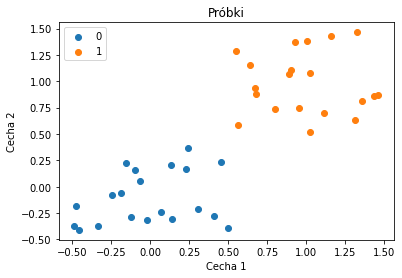

Dodatkowe zasoby:
* `pyplot`: <https://matplotlib.org/tutorials/introductory/pyplot.html>

In [47]:
print(len(train_new[4]), len(train_new[8]))

132 132


In [48]:
train_new

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
1,5.0,4.0,0.936710,2.415100,0.729800,0.817930,0.864910,0.334390,0.080539,1.180500,0.048722,0.120510,0.014314,0.003998,0.000372,1.308300
8,5.0,6.0,0.909440,2.113900,0.695550,0.808730,0.852630,0.310390,0.047267,0.406630,0.039446,0.105170,0.010939,0.002891,0.000294,1.160200
19,3.0,8.0,0.565990,1.042700,0.353180,0.890860,0.998250,0.620680,0.032971,0.197850,0.026348,0.105890,0.011088,0.004651,0.000052,0.626710
44,5.0,2.0,0.880750,1.736000,0.583450,0.833830,0.917540,0.415510,0.040582,0.299730,0.035786,0.100470,0.009993,0.002759,0.000258,1.095200
54,5.0,12.0,0.821350,1.603500,0.602500,0.849810,0.875440,0.313040,0.056079,0.572360,0.069239,0.163190,0.025940,0.009292,0.000321,1.468600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2169,5.0,5.0,0.857690,2.277905,0.612994,0.817417,1.003127,0.346316,0.040852,0.321097,0.063552,0.140577,0.019954,0.008255,0.000285,1.364990
2190,5.0,9.0,0.971131,1.413906,0.578289,0.721544,0.779740,0.324182,0.049910,0.555985,0.066759,0.154062,0.022749,0.007653,0.000204,1.483393
2212,3.0,7.0,0.707130,0.720845,0.376911,0.889243,0.892134,0.712109,0.035523,0.243237,0.064845,0.177120,0.027757,0.010349,0.000218,1.338831
2214,5.0,10.0,0.775259,2.044054,0.628758,0.724776,0.841946,0.346136,0.056415,0.433102,0.060213,0.177968,0.026030,0.010985,0.000208,1.272844


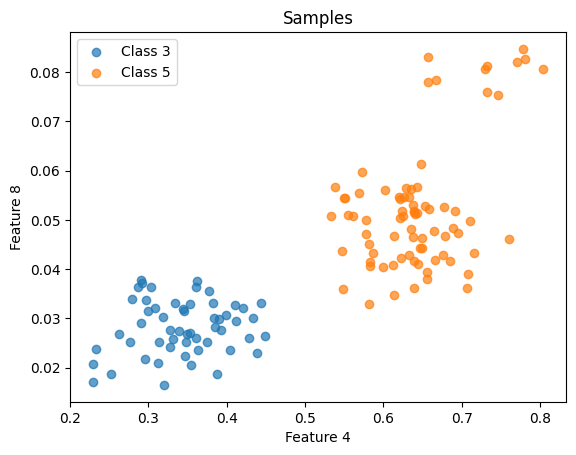

In [49]:
import matplotlib.pyplot as plt
plt.figure()
plt.title("Samples")
plt.xlabel(f"Feature 4")
plt.ylabel(f"Feature 8")

for class_id in [3, 5]:
    class_data=train_new[train_new[0]==class_id]
    plt.scatter(
        x=class_data[4], 
        y=class_data[8],
        label=f"Class {class_id}",
        alpha=0.7
    )

plt.legend()

### Zadanie 5

Zaimplementuj funkcję `edist`, która zwróci _odległość Euklidesa_ pomiędzy punktami `x` i `y` uwzględniając wybrane cechy `features`.

$$
d(x, y) = \sqrt{\sum^{n-1}_{i=0}{(x_i - y_i)^2}}
$$


In [ ]:
features = [1, 2] # kolumny o indeksach 1, 2
x = [0, 2, 3]
y = [0, 5, 6]

def edist(x, y, features):
    x = np.array(x)
    y = np.array(y)

    x_features = x[features]
    y_features = y[features]
    
    return np.sqrt(np.sum((x_features-y_features)**2))

edist(x, y, features) # wynik: 4.242640687119285

4.242640687119285

### Zadanie 6  

Zaimplementuj klasyfikator **najbliższego sąsiada** (*k-Nearest Neighbor*).  

1. Oblicz odległość każdego elementu ze zbioru **testowego** do każdego elementu ze zbioru **treningowego**.  
2. Znajdź element ze zbioru **treningowego**, który znajduje się najbliżej klasyfikowanego elementu ze zbioru **testowego**.  
3. Przypisz klasyfikowanemu elementowi klasę najbliższego sąsiada.  


In [98]:
features = [i for i in range(2,16)]
for index_test, row_test in test_df.iterrows():
    dist = float('inf')
    closest_train_idx = -1
    for index_train, row_train in train_df.iterrows():
        edistance = edist(row_train,row_test,features)
        if edistance < dist:
            dist = edistance
            closest_train_idx = index_train
    print(dist, closest_train_idx)
    print(f"Test class: {test_df[0][index_test]}, closest train class: {train_df[0][closest_train_idx]}")
    break

0.1972313037583574 708
Test class: 31.0, closest train class: 34.0


In [52]:
new_test = test_new.copy()
new_train = train_new.copy()

new_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
10,3.0,3.0,0.612890,1.099100,0.331170,0.924050,0.984210,0.616610,0.025545,0.118770,0.054687,0.160600,0.025145,0.011672,0.000121,1.107600
31,3.0,10.0,0.595710,1.084000,0.325920,0.920560,0.998250,0.656980,0.024753,0.111510,0.042051,0.147220,0.021213,0.010881,0.000065,0.832210
68,5.0,11.0,0.822680,1.665700,0.599090,0.844930,0.856140,0.320560,0.048803,0.433480,0.079282,0.185710,0.033338,0.013523,0.000275,1.537700
75,5.0,8.0,0.936130,2.389800,0.671750,0.844340,0.905260,0.370070,0.039277,0.280770,0.048447,0.119550,0.014091,0.003789,0.000425,1.259300
76,5.0,7.0,0.894930,2.049400,0.649250,0.816820,0.835090,0.353180,0.049955,0.454180,0.041808,0.120360,0.014280,0.004801,0.000171,1.096200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,3.0,9.0,0.638268,1.379693,0.415194,0.929630,0.901990,0.565649,0.033198,0.143643,0.057462,0.160330,0.030170,0.013677,0.000099,1.247396
1446,3.0,4.0,0.716864,1.435558,0.411318,1.061540,1.073423,0.751770,0.021441,0.011297,0.034744,0.108187,0.015146,0.005625,0.000101,0.886472
1466,5.0,3.0,0.886221,2.178478,0.573496,0.905184,0.912196,0.319765,0.048404,0.362463,0.034861,0.134169,0.011128,0.004413,0.000210,0.947233
1468,5.0,1.0,0.924960,1.769592,0.575877,0.893757,0.937718,0.361707,0.041139,0.295472,0.044008,0.122080,0.014654,0.004418,0.000207,1.180374


In [100]:
def knn(test, train, features=[i for i in range(2,16)]):
    features = features
    classes = []
    for index_test, row_test in test.iterrows():
        dist = float('inf')
        closest_train_idx = -1
        for index_train, row_train in train.iterrows():
            edistance = edist(row_train,row_test,features)
            if edistance < dist:
                dist = edistance
                closest_train_idx = index_train
        if closest_train_idx == -1:
            raise ValueError("Nie znaleziono najblizszego sasieda")
        classes.append(train_df[0][closest_train_idx])

    test["knn_class"] = classes


knn(new_test,new_train,[4,8])

new_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,knn_class
10,3.0,3.0,0.612890,1.099100,0.331170,0.924050,0.984210,0.616610,0.025545,0.118770,0.054687,0.160600,0.025145,0.011672,0.000121,1.107600,3.0
31,3.0,10.0,0.595710,1.084000,0.325920,0.920560,0.998250,0.656980,0.024753,0.111510,0.042051,0.147220,0.021213,0.010881,0.000065,0.832210,3.0
68,5.0,11.0,0.822680,1.665700,0.599090,0.844930,0.856140,0.320560,0.048803,0.433480,0.079282,0.185710,0.033338,0.013523,0.000275,1.537700,5.0
75,5.0,8.0,0.936130,2.389800,0.671750,0.844340,0.905260,0.370070,0.039277,0.280770,0.048447,0.119550,0.014091,0.003789,0.000425,1.259300,5.0
76,5.0,7.0,0.894930,2.049400,0.649250,0.816820,0.835090,0.353180,0.049955,0.454180,0.041808,0.120360,0.014280,0.004801,0.000171,1.096200,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,3.0,9.0,0.638268,1.379693,0.415194,0.929630,0.901990,0.565649,0.033198,0.143643,0.057462,0.160330,0.030170,0.013677,0.000099,1.247396,3.0
1446,3.0,4.0,0.716864,1.435558,0.411318,1.061540,1.073423,0.751770,0.021441,0.011297,0.034744,0.108187,0.015146,0.005625,0.000101,0.886472,3.0
1466,5.0,3.0,0.886221,2.178478,0.573496,0.905184,0.912196,0.319765,0.048404,0.362463,0.034861,0.134169,0.011128,0.004413,0.000210,0.947233,5.0
1468,5.0,1.0,0.924960,1.769592,0.575877,0.893757,0.937718,0.361707,0.041139,0.295472,0.044008,0.122080,0.014654,0.004418,0.000207,1.180374,5.0


### Zadanie 7
Przeprowadź klasyfikację liści dla wybranych wcześniej dwóch klas, korzystając z własnej implementacji modelu NN.

Następnie wyświetl wyniki klasyfikacji:
* Próbki treningowe i testowe.
* Każdą klasę oznacz innym kolorem.
* Próbki testowe wyróżnij innym markerem.

> Wykorzystaj parametry: `facecolors`, `edgecolors`, `marker` i `c` funkcji `scatter`.

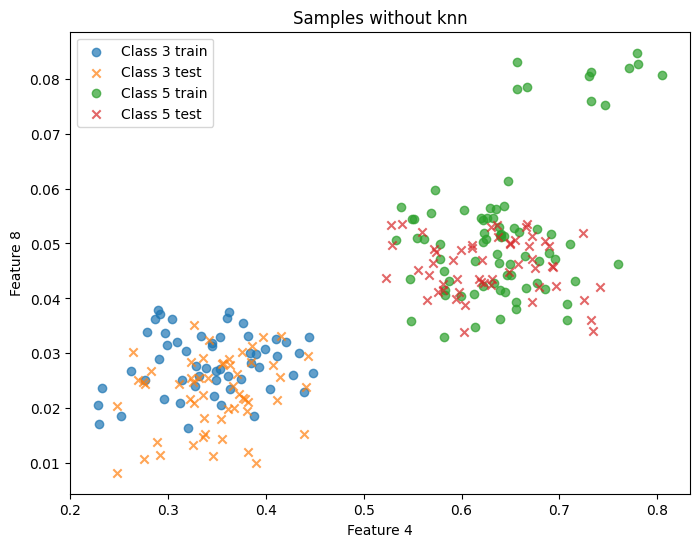

In [121]:
plt.figure(figsize=(8, 6))
plt.title("Samples without knn") 
plt.xlabel(f"Feature 4")
plt.ylabel(f"Feature 8")

for class_id in [3,5]:
    class_data=train_df[train_df[0]==class_id]
    plt.scatter(
        x=class_data[4], 
        y=class_data[8],
        label=f"Class {class_id} train",
        alpha=0.7
    )
    class_data_test=test_df[test_df[0]==class_id]
    plt.scatter(
        x=class_data_test[4], 
        y=class_data_test[8],
        label=f"Class {class_id} test",
        marker="x",
        alpha=0.7
    )

plt.legend()

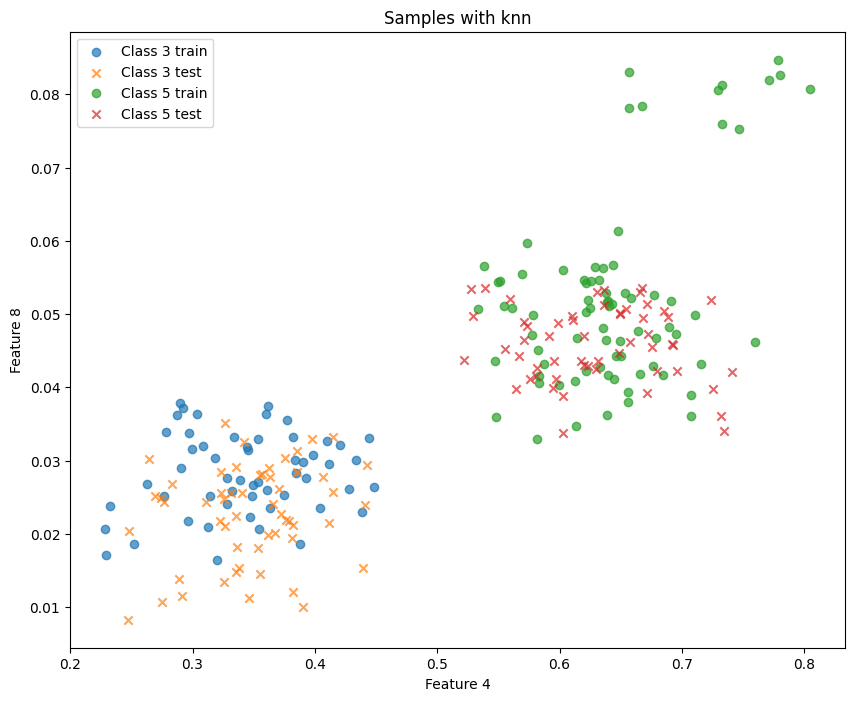

In [120]:
plt.figure(figsize=(10, 8))
plt.title("Samples with knn") 
plt.xlabel(f"Feature 4")
plt.ylabel(f"Feature 8")

for class_id in [3,5]:
    class_data=new_train[new_train[0]==class_id]
    plt.scatter(
        x=class_data[4], 
        y=class_data[8],
        label=f"Class {class_id} train",
        alpha=0.7
    )
    true_positive=new_test[(new_test["knn_class"]==class_id) & (new_test[0] == class_id)]
    if len(true_positive) == 0:
        continue
    plt.scatter(
        x=true_positive[4], 
        y=true_positive[8],
        label=f"Class {class_id} test",
        marker="x",
        alpha=0.7
    )
    false_negative = new_test[(new_test[0]==class_id) & (new_test["knn_class"] != class_id)]
    if len(false_negative) == 0:
        continue
    plt.scatter(
        x=false_negative[4],
        y=false_negative[8],
        label=f"True class {class_id} misclassified",
        marker="o",
        edgecolors='red',
        alpha=1
    )

plt.legend()

### Zadanie 8

Oblicz dokładność (*Accuracy*) klasyfikacji (stosunek poprawnie zaklasyfikowanych próbek do liczby wszystkich próbek wyrażony procentowo).

$$
\texttt{Accuracy} = \frac{T}{N}
$$

gdzie $T$ - liczba poprawnie zaklasyfikowanych próbek, $N$ - liczba wszystkich próbek.


In [109]:
T = len(new_test[new_test[0] == new_test["knn_class"]])
N = len(new_test)
print(f"Accuracy: {T/N:.2%}")

Accuracy: 100.00%


### Zadanie 9

Do zbioru dodaj jeszcze **trzy** dowolne rodzaje liści (klasy) i przeprowadź eksperyment ponownie.

Łącznie zbiór będzie zawierał **pięć** klas. Wynik wciąż należy przedstawić dla tych samych dwóch cech co wcześniej.


In [110]:
test5 = test_df[(test_df[0] == 3) | (test_df[0] == 5) | (test_df[0] == 7) | ((test_df[0] == 9)) | ((test_df[0] == 11))].copy()
train5 = train_df[(train_df[0] == 3) | (train_df[0] == 5) | (train_df[0] == 7) | ((train_df[0] == 9)) | ((train_df[0] == 11))].copy()

print(f"Test unique classes: {sorted(test5[0].unique())}")
print(f"Train unique classes: {sorted(train5[0].unique())}")

Test unique classes: [3.0, 5.0, 7.0, 9.0, 11.0]
Train unique classes: [3.0, 5.0, 7.0, 9.0, 11.0]


In [111]:
knn(test5,train5,[4,8])

test5

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,knn_class
8,9.0,3.0,0.548330,1.273300,0.310930,0.934090,0.998250,0.597070,0.017966,0.058744,0.043685,0.125050,0.015397,0.005104,0.000424,0.946170,9.0
10,3.0,3.0,0.612890,1.099100,0.331170,0.924050,0.984210,0.616610,0.025545,0.118770,0.054687,0.160600,0.025145,0.011672,0.000121,1.107600,3.0
15,11.0,7.0,0.390920,1.087000,0.681740,0.509610,0.661400,0.153610,0.140820,3.609300,0.028638,0.089135,0.007882,0.002118,0.000210,0.900820,11.0
26,11.0,5.0,0.267580,1.131600,0.601280,0.543010,0.773680,0.203110,0.153540,4.290400,0.017945,0.071450,0.005079,0.001465,0.000072,0.632730,11.0
31,3.0,10.0,0.595710,1.084000,0.325920,0.920560,0.998250,0.656980,0.024753,0.111510,0.042051,0.147220,0.021213,0.010881,0.000065,0.832210,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468,5.0,1.0,0.924960,1.769592,0.575877,0.893757,0.937718,0.361707,0.041139,0.295472,0.044008,0.122080,0.014654,0.004418,0.000207,1.180374,7.0
1484,11.0,2.0,0.519524,1.298175,0.674496,0.617641,0.728558,0.210551,0.131087,3.147546,0.022467,0.088671,0.006728,0.002353,0.000044,0.719461,11.0
1485,3.0,2.0,0.761481,1.075421,0.345817,0.868323,1.128896,0.775760,0.011288,0.012503,0.027716,0.096726,0.010567,0.004479,0.000059,0.545181,9.0
1492,11.0,15.0,0.295724,1.059946,0.627790,0.411706,0.610035,0.151498,0.131477,2.940893,0.019995,0.067799,0.004621,0.001654,0.000207,0.853746,11.0


In [112]:
T = len(test5[test5[0] == test5["knn_class"]])
N = len(test5)
print(f"Accuracy: {T/N:.2%}")

Accuracy: 72.73%


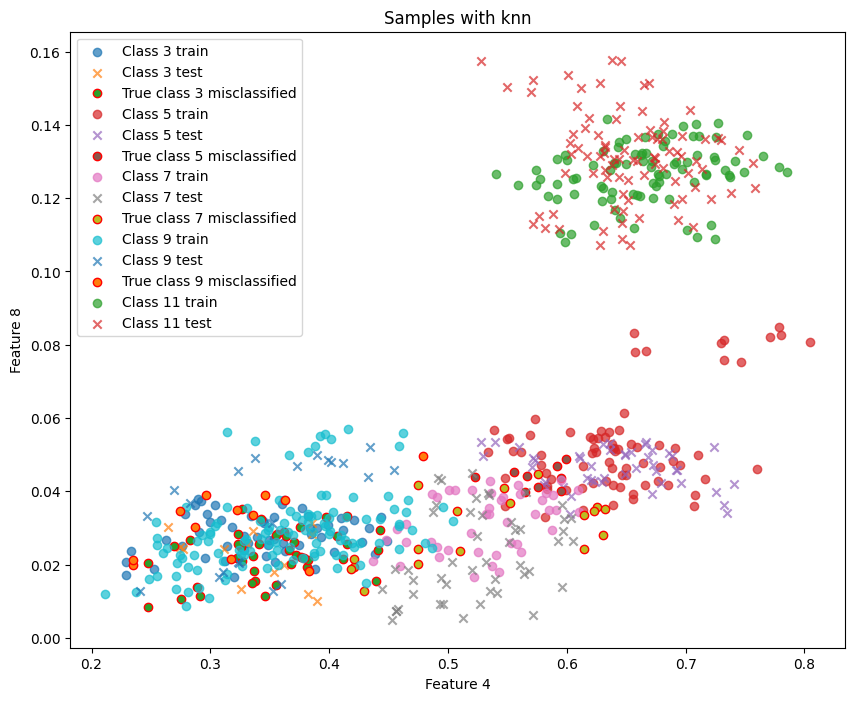

In [119]:
plt.figure(figsize=(10, 8))
plt.title("Samples with knn") 
plt.xlabel(f"Feature 4")
plt.ylabel(f"Feature 8")

for class_id in [3,5,7,9,11]:
    class_data=train5[train5[0]==class_id]
    plt.scatter(
        x=class_data[4], 
        y=class_data[8],
        label=f"Class {class_id} train",
        alpha=0.7
    )
    true_positive=test5[(test5["knn_class"]==class_id) & (test5[0] == class_id)]
    if len(true_positive) == 0:
        continue
    plt.scatter(
        x=true_positive[4], 
        y=true_positive[8],
        label=f"Class {class_id} test",
        marker="x",
        alpha=0.7
    )
    false_negative = test5[(test5[0]==class_id) & (test5["knn_class"] != class_id)]
    if len(false_negative) == 0:
        continue
    plt.scatter(
        x=false_negative[4],
        y=false_negative[8],
        label=f"True class {class_id} misclassified",
        marker="o",
        edgecolors='red',
        alpha=1
    )

plt.legend()

### Zadanie 10

Przeprowadź eksperyment ponownie, używając tych samych parametrów co w zadaniu 9, ale z większą liczbą cech: 3, 5 i 10.

> W tym przypadku nie wyświetlaj wykresu - oblicz jedynie dokładność klasyfikacji.
> Zwiększając liczbę cech, dodawaj nowe cechy, zachowując wcześniejsze.

In [117]:
test5new = test_df[(test_df[0] == 3) | (test_df[0] == 5) | (test_df[0] == 7) | ((test_df[0] == 9)) | ((test_df[0] == 11))].copy()
train5new = train_df[(train_df[0] == 3) | (train_df[0] == 5) | (train_df[0] == 7) | ((train_df[0] == 9)) | ((train_df[0] == 11))].copy()

knn(test5new,train5new,[3,4,5,8,10])

test5new

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,knn_class
8,9.0,3.0,0.548330,1.273300,0.310930,0.934090,0.998250,0.597070,0.017966,0.058744,0.043685,0.125050,0.015397,0.005104,0.000424,0.946170,9.0
10,3.0,3.0,0.612890,1.099100,0.331170,0.924050,0.984210,0.616610,0.025545,0.118770,0.054687,0.160600,0.025145,0.011672,0.000121,1.107600,9.0
15,11.0,7.0,0.390920,1.087000,0.681740,0.509610,0.661400,0.153610,0.140820,3.609300,0.028638,0.089135,0.007882,0.002118,0.000210,0.900820,11.0
26,11.0,5.0,0.267580,1.131600,0.601280,0.543010,0.773680,0.203110,0.153540,4.290400,0.017945,0.071450,0.005079,0.001465,0.000072,0.632730,11.0
31,3.0,10.0,0.595710,1.084000,0.325920,0.920560,0.998250,0.656980,0.024753,0.111510,0.042051,0.147220,0.021213,0.010881,0.000065,0.832210,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468,5.0,1.0,0.924960,1.769592,0.575877,0.893757,0.937718,0.361707,0.041139,0.295472,0.044008,0.122080,0.014654,0.004418,0.000207,1.180374,7.0
1484,11.0,2.0,0.519524,1.298175,0.674496,0.617641,0.728558,0.210551,0.131087,3.147546,0.022467,0.088671,0.006728,0.002353,0.000044,0.719461,11.0
1485,3.0,2.0,0.761481,1.075421,0.345817,0.868323,1.128896,0.775760,0.011288,0.012503,0.027716,0.096726,0.010567,0.004479,0.000059,0.545181,3.0
1492,11.0,15.0,0.295724,1.059946,0.627790,0.411706,0.610035,0.151498,0.131477,2.940893,0.019995,0.067799,0.004621,0.001654,0.000207,0.853746,11.0


In [118]:
T = len(test5new[test5new[0] == test5new["knn_class"]])
N = len(test5new)
print(f"Accuracy: {T/N:.2%}")

Accuracy: 77.10%


### Zadanie 11

Napisz wnioski z przeprowadzonego eksperymentu.

* knn properly distinguish two classes of leaves
* accuracy drops when increasing number of classes to 5
* when more features, the better classificator can classify leaves if more than two classes
* when two classes are close together, the risk of misclassification increases